In [6]:
import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pyquaternion import Quaternion
import transforms3d.euler

def analyze_run(DATA_DIR):
    # ————————————————————————————————————————————————
    # 1) Load mismatch.csv
    mm = pd.read_csv(os.path.join(DATA_DIR, "mismatch_0.csv"))
    t_mm    = mm["timestep"].values
    exp_pts = mm[["exp_x","exp_y","exp_z"]].values
    act_pts = mm[["act_x","act_y","act_z"]].values

    # 3D scatter
    fig = plt.figure(figsize=(9,7))
    ax  = fig.add_subplot(111, projection='3d')
    tn = (t_mm - t_mm.min())/(t_mm.max()-t_mm.min())
    sc1 = ax.scatter(*exp_pts.T, c=tn, cmap="Blues", marker="o", s=30, label="Expected")
    sc2 = ax.scatter(*act_pts.T, c=tn, cmap="Reds", marker="^", s=30, alpha=0.8, label="Actual")
    cbar1 = fig.colorbar(sc1, ax=ax, shrink=0.5, pad=0.1); cbar1.set_label("Expected time (norm.)")
    cbar2 = fig.colorbar(sc2, ax=ax, shrink=0.5, pad=0.02); cbar2.set_label("Actual time (norm.)")
    ax.set_title("Expected vs. Actual End-Effector Trajectories")
    ax.set_xlabel("X (m)"); ax.set_ylabel("Y (m)"); ax.set_zlabel("Z (m)")
    ax.legend()
    plt.show()

    # ————————————————————————————————————————————————
    # 2) Plot error & delta-error
    errors      = np.linalg.norm(exp_pts - act_pts, axis=1)
    delta_err   = errors[1:] - errors[:-1]
    t_de        = t_mm[1:]

    fig, (ax1, ax2) = plt.subplots(2,1, figsize=(9,6), sharex=True)
    ax1.plot(t_mm, errors, 'o-', color='k')
    ax1.set_ylabel("Error norm (m)")
    ax1.set_title("End-Effector Tracking Error Over Time")
    ax1.grid(True)

    ax2.plot(t_de, delta_err, 'x-', color='magenta')
    ax2.axhline(0, color='gray', linestyle='--')
    ax2.set_xlabel("Timestep")
    ax2.set_ylabel("ΔError (m)")
    ax2.set_title("Frame-to-Frame Change in Error")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    # ————————————————————————————————————————————————
    # 3) Load log_0.csv
    log = pd.read_csv(os.path.join(DATA_DIR, "log_0.csv"))
    for col in ['delta_ik','delta_post']:
        log[f"{col}_arr"] = log[col].apply(ast.literal_eval).apply(np.array)

    t   = log['timestep'].values
    des = np.vstack([log['desired_ee_pos_world_x'],
                     log['desired_ee_pos_world_y'],
                     log['desired_ee_pos_world_z']]).T
    act = np.vstack([log['ee_pos_world_x'],
                     log['ee_pos_world_y'],
                     log['ee_pos_world_z']]).T

    dp  = np.vstack(log['delta_post_arr'].values)
    dik = np.vstack(log['delta_ik_arr'].values)
    js_err = np.linalg.norm(dp, axis=1)
    ik_err = np.linalg.norm(dik, axis=1)

    # Desired vs actual X/Y/Z
    fig, axes = plt.subplots(3,1, figsize=(8,10), sharex=True)
    for i,(ax,lab) in enumerate(zip(axes, "XYZ")):
        ax.plot(t, des[:,i], '--', label=f"desired {lab}")
        ax.plot(t, act[:,i],  '-', label=f"actual  {lab}")
        ax.set_ylabel(f"{lab} (m)")
        ax.grid(True)
        ax.legend(loc='upper left')
    axes[-1].set_xlabel("Timestep")
    fig.suptitle("Desired vs Actual EE Position Components", y=0.92)
    plt.tight_layout()
    plt.show()

    # Joint-space vs IK residual
    plt.figure(figsize=(8,3))
    plt.plot(t, js_err, label="||Δ_post|| (tracking)")
    plt.plot(t, ik_err, label="||Δ_ik|| (IK residual)")
    plt.xlabel("Timestep"); plt.ylabel("Norm")
    plt.title("Joint-space Tracking vs IK Residual")
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.show()

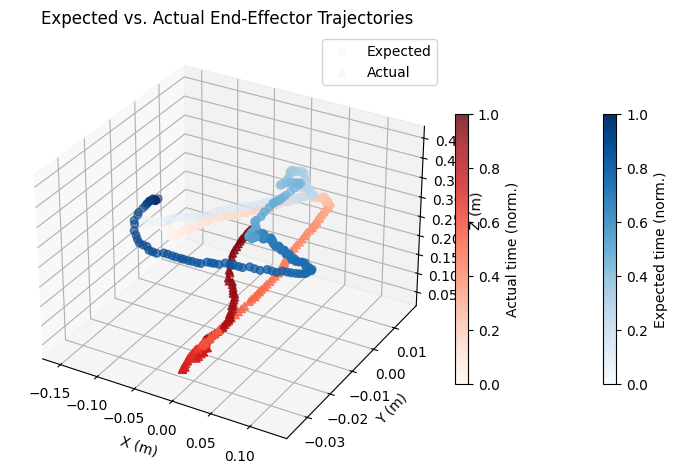

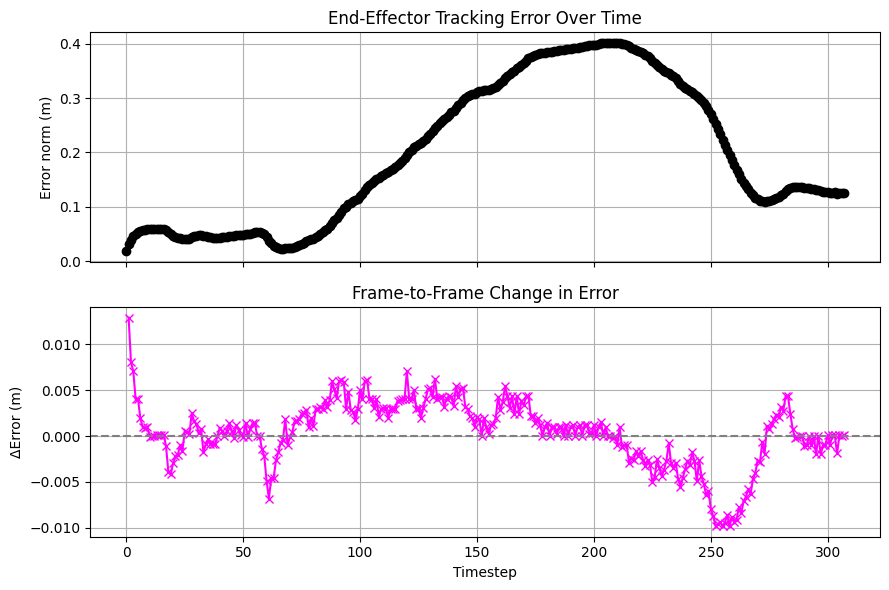

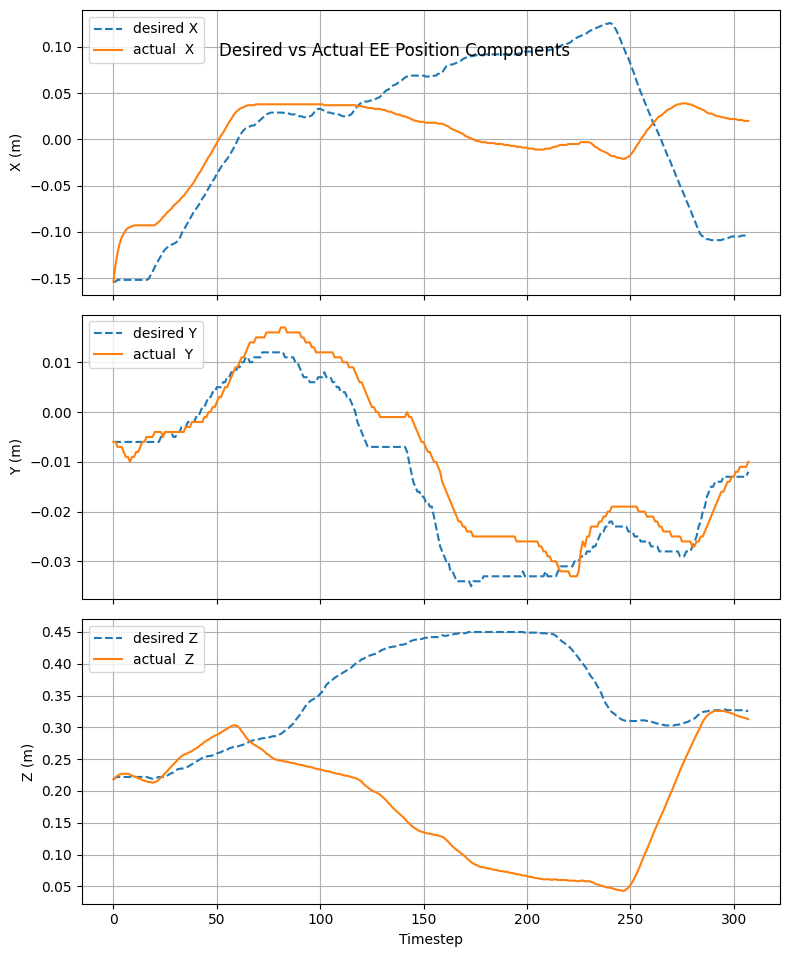

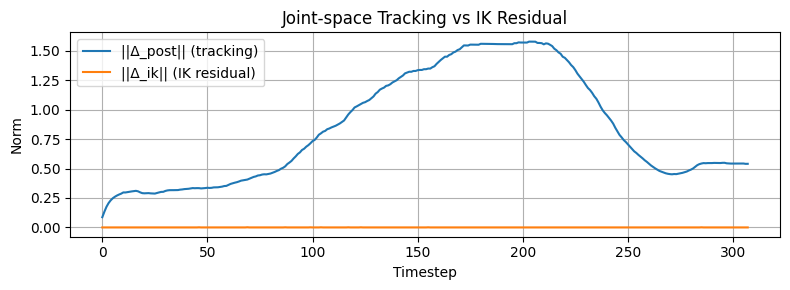

In [7]:
analyze_run("/home/maksymbondarenko/Desktop/gendp/datasets/20250512_171706")


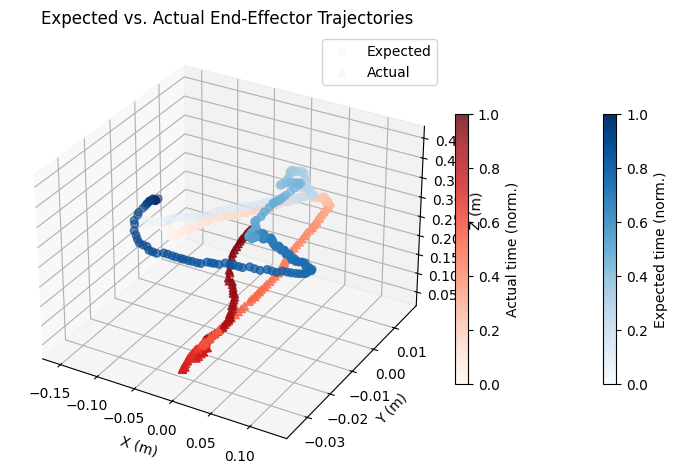

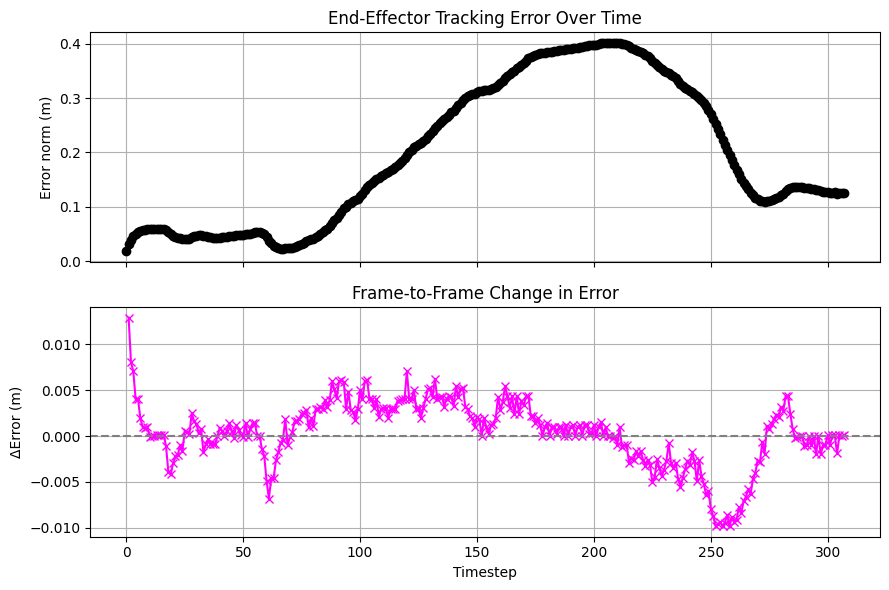

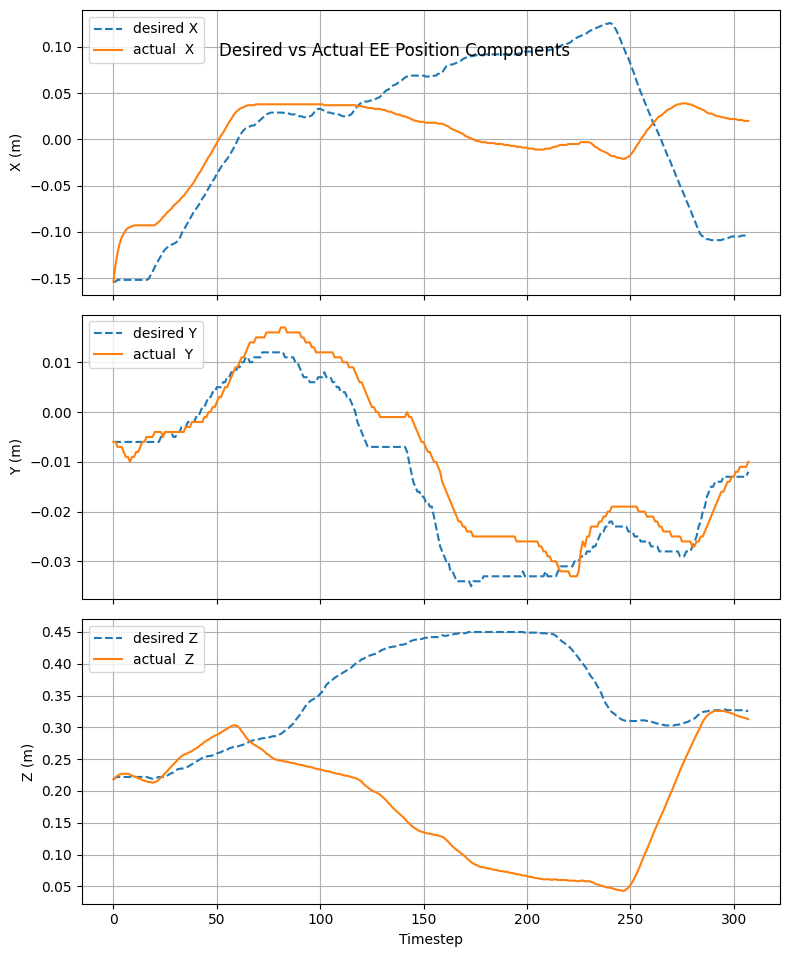

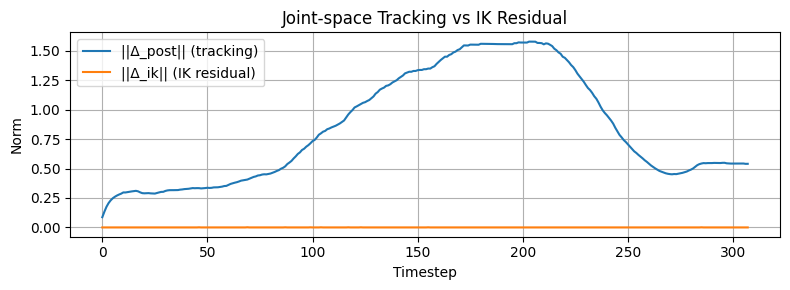

In [8]:
analyze_run("/home/maksymbondarenko/Desktop/gendp/datasets/20250512_174022")